In [9]:
# --- Project setup: portable paths (no hard-coded absolute paths) ---
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT = next(p for p in (_cwd, *_cwd.parents) if (p / "project_paths.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from project_paths import DATA_DIR, MODELS_DIR

In [32]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# 1. Speicherpfad definieren (muss mit dem Namen beim Speichern übereinstimmen)
model_filename = MODELS_DIR / "best_RF_classifier_SOAP_bandgap.joblib"

# 2. Das Modell laden
try:
    loaded_rf_model = joblib.load(model_filename)
    print(f"Modell erfolgreich geladen aus: {model_filename}")
except FileNotFoundError:
    print(f"Fehler: Die Datei '{model_filename}' wurde nicht gefunden. Überprüfe den Pfad.")

Modell erfolgreich geladen aus: /Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/models/best_RF_classifier_SOAP_bandgap.joblib


In [37]:
import pandas as pd
import numpy as np

# 1. Metadaten laden
df_meta = pd.read_csv(DATA_DIR / "perovskite_metadata_overview_reduced.csv")
print("Ursprüngliche Meta-Form:", df_meta.shape)

# 2. Hocheffiziente SOAP-Features laden (X)
X = np.load(DATA_DIR / "perovskite_soap_features_reduced.npy")
print("Ursprüngliche X-Form:", X.shape)

# 3. NaNs NUR in df_meta löschen (wichtig: inplace=True belassen wir so, oder machen es explizit)
df_meta.dropna(subset=['band_gap'], inplace=True)

# 4. SYNCHRONISATION: Nutze die verbliebenen Indizes, um X zu filtern
# df_meta.index enthält jetzt nur noch die Indizes der Zeilen, die NICHT gelöscht wurden
X = X[df_meta.index]

# 5. Target y erstellen
y = df_meta["is_metal"].values  # Jetzt passen X und y perfekt zusammen!

print('Neue X-Form:        ', X.shape)
print('Neue Meta-Form (y): ', df_meta.shape)
print('Number of entries:  ', df_meta.shape[0])
df_meta.head()

Ursprüngliche Meta-Form: (8000, 10)
Ursprüngliche X-Form: (8000, 48870)
Neue X-Form:         (7971, 48870)
Neue Meta-Form (y):  (7971, 10)
Number of entries:   7971


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [38]:
df_meta['band_gap'].isna().sum()

np.int64(0)

In [39]:
from sklearn.model_selection import train_test_split

# Angenommen, deine Metadaten liegen in einem Pandas DataFrame oder NumPy Array namens `meta`
# Wichtig: meta.shape[0] muss genau so groß sein wie X.shape[0]

# Du übergibst meta einfach als zusätzliches Argument:
X_train, X_test, y_train, y_test, cs_train, cs_test, bg_train, bg_test, he_train, he_test = train_test_split(
    X, 
    y, 
    df_meta['crystal_structure'], 
    df_meta['band_gap'],
    df_meta['energy_above_hull'],
    test_size=0.2, random_state=42
)

print("X_train Form:", X_train.shape)
print("meta_train Form:", bg_train.shape) # Die Zuordnung bleibt perfekt erhalten!

X_train Form: (6376, 48870)
meta_train Form: (6376,)


In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = loaded_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    ))

Model Accuracy: 0.97

Classification Report:
                     precision    recall  f1-score   support

Kein Metall (False)       0.93      0.97      0.95       477
      Metall (True)       0.99      0.97      0.98      1118

           accuracy                           0.97      1595
          macro avg       0.96      0.97      0.96      1595
       weighted avg       0.97      0.97      0.97      1595



In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model,x_test, y_test, labels_x, labels_y):

    y_pred = model.predict(x_test)

    # 1. Die Confusion Matrix normalisieren ('true' normiert über die tatsächliche Achse)
    cm_percentage = confusion_matrix(y_test, y_pred, normalize="true")

    # 2. Beschriftungen für die Achsen definieren
    #labels_y = ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"]
    #labels_x = ["Kein Metall\n(False)", "Metall\n(True)"]

    # 3. Den Plot erstellen
    plt.figure(figsize=(6, 5))

    # sns.heatmap zeichnet die Matrix
    sns.heatmap(
        cm_percentage,
        annot=True,  # Schreibt die Werte in die Quadrate
        fmt=".1%",  # <--- WICHTIG: Formatiert die Zahlen als Prozent mit einer Nachkommastelle (z.B. 94.5%)
        cmap="Blues",  # Blaue Farbpalette
        xticklabels=labels_x,  # Beschriftung X-Achse
        yticklabels=labels_y,  # Beschriftung Y-Achse
        cbar=True,
        square=True,
        vmin=0,
        vmax=1,  # Setzt die Farbskala fest von 0% bis 100%
    )

    # 4. Titel und Achsenbeschriftungen
    plt.title(
        "Confusion Matrix (Prozentual) - Metall-Klassifikation",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Vorhersage des Modells (Predicted)", fontsize=12)
    plt.ylabel("Tatsächliche Struktur (Actual)", fontsize=12)

    # Grafik anzeigen
    plt.tight_layout()
    plt.show()

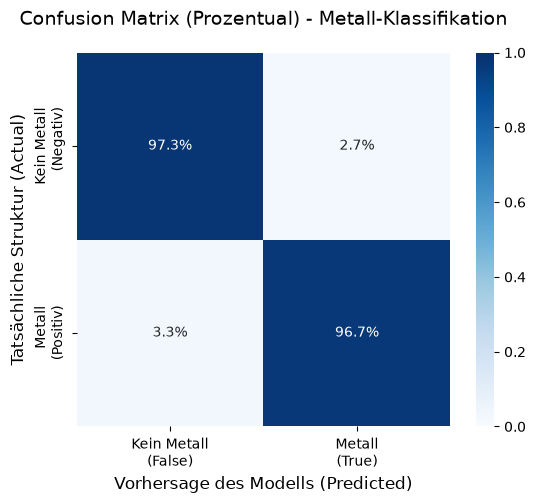

In [43]:
plot_confusion_matrix(loaded_rf_model, X_test, y_test, ["Kein Metall\n(False)", "Metall\n(True)"], ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"])


## Schritt 2: Band-Gap-Regression auf Halbleitern

Der Classifier oben trennt **Metall** von **Nicht-Metall**. Im zweiten Schritt sagt ein
`RandomForestRegressor` den konkreten **Band-Gap-Wert** fuer die Halbleiter (`is_metal == False`)
voraus. Metalle haben per Definition einen Band Gap von 0 eV und werden daher nicht regressiert.

Zur Bewertung wird eine **Wahr-vs-Vorhergesagt-Diagonale** geplottet: Punkte nahe der roten
`y = x`-Linie bedeuten gute Vorhersagen.

> Hinweis zur Waldgroesse: Wir haben ~48.900 SOAP-Features. Damit der Wald handhabbar bleibt,
> setzen wir `max_features='sqrt'` (statt Default = alle Features pro Split) sowie moderate
> `n_estimators` und `min_samples_leaf`.

In [44]:
print(bg_train.isna().sum())

0


In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Halbleiter = Nicht-Metalle (is_metal == False, band_gap > 0).
# Wir verwenden GENAU denselben Train/Test-Split wie beim Classifier -> keine Data-Leakage.
bg_train_arr = np.asarray(bg_train)
bg_test_arr = np.asarray(bg_test)

mask_train_semi = (y_train == False)   # nur Halbleiter im Trainingsset
mask_test_semi = (y_test == False)     # nur Halbleiter im Testset

X_train_sc = X_train[mask_train_semi]
y_train_sc = bg_train_arr[mask_train_semi]

X_test_sc = X_test[mask_test_semi]
y_test_sc = bg_test_arr[mask_test_semi]

print(f"Halbleiter im Training: {X_train_sc.shape[0]}")
print(f"Halbleiter im Test:     {X_test_sc.shape[0]}")
print(f"Band-Gap-Bereich (Train): {y_train_sc.min():.2f} - {y_train_sc.max():.2f} eV")

Halbleiter im Training: 1946
Halbleiter im Test:     477
Band-Gap-Bereich (Train): 0.17 - 7.94 eV


In [56]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor

# Base-Modell definieren (n_jobs=-1 hier setzen, damit alle Kerne genutzt werden)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Das Parameter-Grid: Kompakt gehalten wegen der hohen Feature-Anzahl
param_grid = {
    # 200 ist solide, wir prüfen ob 150 reicht (spart Zeit) oder 300 spürbar besser ist
    'n_estimators': [150, 200, 300],
    
    # 'sqrt' ist gesetzt (~221 Features). Wir testen 'log2' (~16 Features) für extremen Speedup
    'max_features': ['sqrt', 'log2'],
    
    # Verhindert, dass Bäume bis ins unendliche wachsen (Speicherschutz)
    'max_depth': [15, 25, None],
    
    # Größere Blätter glätten und verkleinern das Modell (wichtig bei SOAP)
    'min_samples_leaf': [2, 4, 6]
}

# Kreuzvalidierung definieren (z.B. 5-Fold)
# shuffle=True ist wichtig, da Daten oft vorsortiert sind
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch Setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='r2',           # Oder 'neg_mean_squared_error'
    n_jobs=1,               # WICHTIG: Auf 1 lassen, da RandomForest intern bereits n_jobs=-1 nutzt!
    verbose=2               # Zeigt dir den Fortschritt live an
)

# GridSearch starten
print("Starte GridSearch...")
grid_search.fit(X_train_sc, y_train_sc)

# Ergebnisse ausgeben
print(f"Beste Parameter: {grid_search.best_params_}")
print(f"Bester R²-Score: {grid_search.best_score_:.4f}")

# Das beste Modell direkt extrahieren
best_rf_regressor = grid_search.best_estimator_

Starte GridSearch...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=150; total time=   1.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=150; total time=   0.9s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=150; total time=   0.9s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=150; total time=   0.9s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=150; total time=   0.9s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=15, max

In [86]:
# Vorhersage auf den (wahren) Halbleitern im Testset
y_pred_sc = best_rf_regressor.predict(X_test_sc)

r2 = r2_score(y_test_sc, y_pred_sc)
mae = mean_absolute_error(y_test_sc, y_pred_sc)
rmse = np.sqrt(mean_squared_error(y_test_sc, y_pred_sc))

print(f"R^2  : {r2:.3f}")
print(f"MAE  : {mae:.3f} eV")
print(f"RMSE : {rmse:.3f} eV")

R^2  : 0.719
MAE  : 0.644 eV
RMSE : 0.853 eV


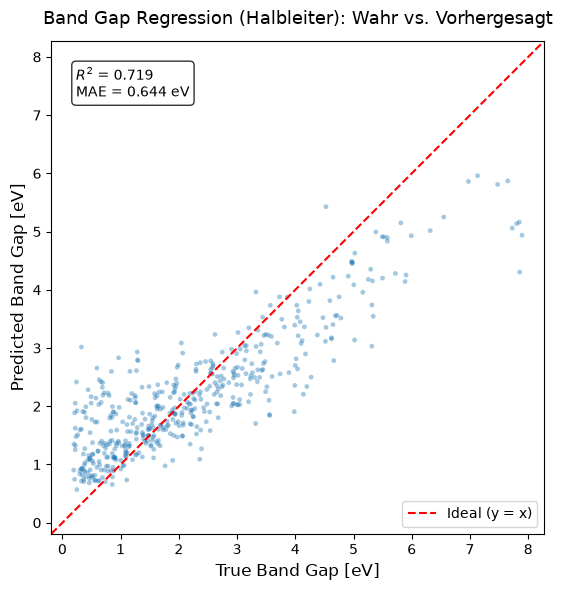

In [87]:
def plot_true_vs_pred(y_true, y_pred, title="Band Gap: Wahr vs. Vorhergesagt"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    pad = 0.05 * (hi - lo)
    lims = [lo - pad, hi + pad]

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=12, alpha=0.4, edgecolor="none")
    plt.plot(lims, lims, "r--", lw=1.5, label="Ideal (y = x)")
    plt.xlim(lims)
    plt.ylim(lims)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("True Band Gap [eV]", fontsize=12)
    plt.ylabel("Predicted Band Gap [eV]", fontsize=12)
    plt.title(title, fontsize=13, pad=12)
    plt.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f} eV",
        transform=plt.gca().transAxes, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8),
    )
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# Diagonale Wahr-vs-Vorhergesagt fuer die (wahren) Halbleiter im Test
plot_true_vs_pred(y_test_sc, y_pred_sc,
                  title="Band Gap Regression (Halbleiter): Wahr vs. Vorhergesagt")

## Try XgBoost

In [63]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold

# 1. Base-Modell definieren
# 'hist' als Tree-Methode ist bei großen Datensätzen/vielen Features UM WELTEN schneller!
xgb_regressor = xgb.XGBRegressor(
    tree_method='hist', 
    random_state=42, 
    n_jobs=-1
)

# 2. Das Parameter-Grid (angepasst an hohe Dimensionalität)
param_grid = {
    # Anzahl der Bäume (Boosting-Runden)
    'n_estimators': [150, 300],
    
    # Lernrate: Kleinere Werte verhindern Overfitting, brauchen aber mehr Bäume
    'learning_rate': [0.05, 0.1],
    
    # Maximale Tiefe der Bäume (XGBoost baut flachere Bäume als Random Forest, meist 3-10)
    'max_depth': [6, 9],
    
    # Entspricht max_features='sqrt'. 0.01 bedeutet, dass pro Baum nur 1% aller Features 
    # (~490 Features) zufällig ausgewählt werden. Schützt vor RAM-Absturz!
    'colsample_bytree': [0.01, 0.05]
}

# 3. Kreuzvalidierung (analog zum Random Forest für fairen Vergleich)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. GridSearch Setup
grid_search_xgb = GridSearchCV(
    estimator=xgb_regressor,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=1, # Parallelisierung dem XGBoost-Modell überlassen
    verbose=2
)

# 5. GridSearch starten
print("Starte XGBoost GridSearch...")
grid_search_xgb.fit(X_train_sc, y_train_sc)

# Ergebnisse ausgeben
print(f"Beste XGBoost Parameter: {grid_search_xgb.best_params_}")
print(f"Bester XGBoost R²-Score: {grid_search_xgb.best_score_:.4f}")

# Bestes Modell sichern
best_xgb_regressor = grid_search_xgb.best_estimator_

Starte XGBoost GridSearch...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=150; total time=   5.2s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=150; total time=   4.8s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=150; total time=   4.6s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=150; total time=   4.7s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=150; total time=   4.7s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=300; total time=   8.2s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=300; total time=   8.4s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=300; total time=   8.4s
[CV] END colsample_bytree=0.01, learning_rate=0.05, max_depth=6, n_estimators=300; total time=

In [91]:
# Vorhersage auf den (wahren) Halbleitern im Testset
y_pred_sc = best_xgb_regressor.predict(X_test_sc)

r2 = r2_score(y_test_sc, y_pred_sc)
mae = mean_absolute_error(y_test_sc, y_pred_sc)
rmse = np.sqrt(mean_squared_error(y_test_sc, y_pred_sc))


print('Performance reiner Regressor')
print(f"R^2  : {r2:.3f}")
print(f"MAE  : {mae:.3f} eV")
print(f"RMSE : {rmse:.3f} eV")

Performance reiner Regressor
R^2  : 0.839
MAE  : 0.449 eV
RMSE : 0.645 eV


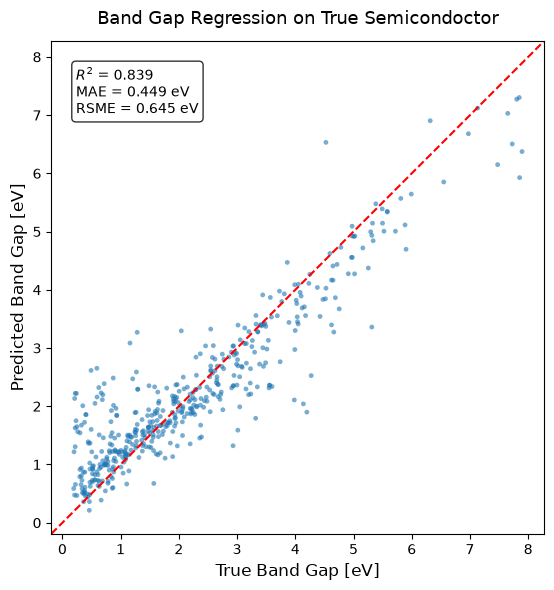

In [89]:
def plot_true_vs_pred(y_true, y_pred, title="Band Gap: Wahr vs. Vorhergesagt"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    pad = 0.05 * (hi - lo)
    lims = [lo - pad, hi + pad]

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolor="none")
    plt.plot(lims, lims, "r--", lw=1.5, label="Ideal (y = x)")
    plt.xlim(lims)
    plt.ylim(lims)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("True Band Gap [eV]", fontsize=12)
    plt.ylabel("Predicted Band Gap [eV]", fontsize=12)
    plt.title(title, fontsize=13, pad=12)
    plt.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f} eV\nRSME = {rmse:.3f} eV",
        transform=plt.gca().transAxes, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8),
    )
    #plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# Diagonale Wahr-vs-Vorhergesagt fuer die (wahren) Halbleiter im Test
plot_true_vs_pred(y_test_sc, y_pred_sc,
                  title="Band Gap Regression on True Semicondoctor")

### Bonus: End-to-End-Pipeline (Classifier &rarr; Regressor)

Bisher wurde der Regressor auf den **wahren** Halbleitern ausgewertet. In der Praxis
entscheidet aber zuerst der Classifier, welche Strukturen Halbleiter sind. Hier die
realistische Kette: Klassifiziere alle Test-Samples, setze vorhergesagte Metalle auf
`band_gap = 0` und wende den Regressor nur auf die als Halbleiter vorhergesagten Samples an.
Der R&sup2;/MAE-Wert liegt hier naturgem&auml;&szlig; etwas schlechter, weil auch Fehlklassifikationen einflie&szlig;en.

Performance End-to-End Pipeline (Classifier + Regressor)
End-to-End  R^2 : 0.906
End-to-End  MAE : 0.163 eV
End-to-End  RMSE : 0.410 eV


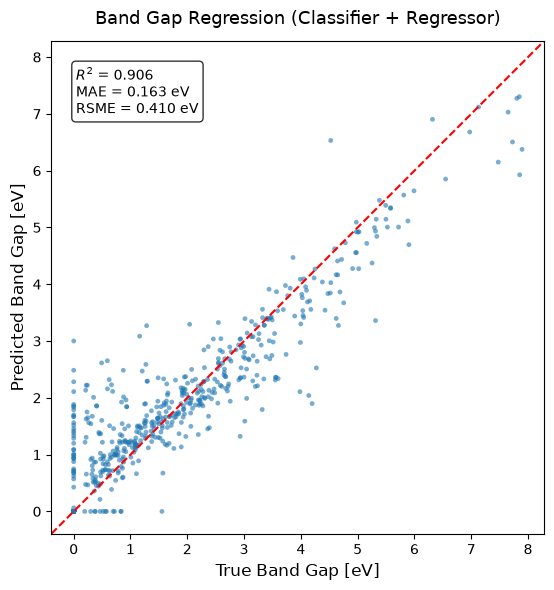

In [92]:
# Realistische Pipeline: erst klassifizieren, dann NUR auf vorhergesagten Halbleitern regressieren.
y_class_pred = loaded_rf_model.predict(X_test)          # True = Metall
pred_semi_mask = (y_class_pred == False)                # vom Classifier als Halbleiter eingestuft

bg_pred_pipeline = np.zeros(X_test.shape[0])            # Metalle -> Band Gap = 0
bg_pred_pipeline[pred_semi_mask] = best_xgb_regressor.predict(X_test[pred_semi_mask])

# Vergleich gegen den wahren Band Gap ueber ALLE Test-Samples (inkl. Classifier-Fehler)
r2_pipe = r2_score(bg_test_arr, bg_pred_pipeline)
mae_pipe = mean_absolute_error(bg_test_arr, bg_pred_pipeline)
rmse_pipe = np.sqrt(mean_squared_error(bg_test_arr, bg_pred_pipeline))
print('Performance End-to-End Pipeline (Classifier + Regressor)')
print(f"End-to-End  R^2 : {r2_pipe:.3f}")
print(f"End-to-End  MAE : {mae_pipe:.3f} eV")
print(f"End-to-End  RMSE : {rmse_pipe:.3f} eV")

plot_true_vs_pred(bg_test_arr, bg_pred_pipeline,
                  title="Band Gap Regression (Classifier + Regressor)")

### Fairer Vergleich: reiner Regressor vs. End-to-End-Pipeline

Achtung beim direkten Vergleich der Zahlen oben: Der **reine Regressor** (R&sup2;=0.839, MAE=0.449 eV)
wird **nur auf den wahren Halbleitern** bewertet, die **Pipeline** (R&sup2;=0.906, MAE=0.163 eV)
dagegen auf **allen** Test-Samples. Das sind **unterschiedliche Populationen** &ndash; die Pipeline
bekommt die vielen Metalle (Ziel = 0 eV) geschenkt, die der 97 %-Classifier fast perfekt auf 0 setzt.
Das bl&auml;ht R&sup2; auf (gr&ouml;&szlig;ere Gesamt-Varianz) und verd&uuml;nnt MAE/RMSE (viele Fehler &asymp; 0).

Ein **fairer** Vergleich misst beide auf **derselben** Population (den wahren Halbleitern).
Dann gilt **B &le; A**: die Pipeline ist dort nicht besser, sondern durch Fehlklassifikationen
(Halbleiter f&auml;lschlich als Metall &rarr; hart auf 0 gesetzt) sogar leicht schlechter.

In [ ]:
# ================================================================
# Fairer Vergleich: reiner Regressor vs. End-to-End-Pipeline
# Die Zahlen "reiner Regressor" (nur Halbleiter) und "Pipeline" (ALLE Samples)
# werden auf UNTERSCHIEDLICHEN Mengen berechnet -> nicht direkt vergleichbar.
# Fair ist nur der Vergleich auf DERSELBEN Population (den wahren Halbleitern).
# ================================================================
true_semi = (y_test == False)   # wahre Halbleiter (Ziel > 0)  == mask_test_semi
true_metal = (y_test == True)   # wahre Metalle (Ziel = 0)

def _row(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        "Szenario": name,
        "n": len(y_true),
        "R2": r2_score(y_true, y_pred),
        "MAE [eV]": mean_absolute_error(y_true, y_pred),
        "RMSE [eV]": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

cmp = pd.DataFrame([
    # A) reiner Regressor, nur wahre Halbleiter -> Best Case (Labels perfekt bekannt)
    _row("A) Reiner Regressor - nur wahre Halbleiter", y_test_sc, y_pred_sc),
    # B) Pipeline, aber NUR auf denselben wahren Halbleitern -> fairer Vergleich zu A
    _row("B) Pipeline - nur wahre Halbleiter", bg_test_arr[true_semi], bg_pred_pipeline[true_semi]),
    # C) Pipeline auf ALLEN Samples -> die "geschoente" Zahl (dominiert von Metallen mit Ziel 0)
    _row("C) Pipeline - ALLE Samples (inkl. Metalle)", bg_test_arr, bg_pred_pipeline),
]).set_index("Szenario")

print(cmp.round(3).to_string())

# --- Warum ist C scheinbar am besten? Zerlegung des gepoolten MAE nach wahren Gruppen ---
# Alle Fehler sind per Instanz normiert (MAE = mittlerer |Fehler| pro Sample).
# Es gilt exakt:  MAE_gesamt(C) = Summe ueber Gruppen von (n_Gruppe / N) * MAE_Gruppe
abs_err = np.abs(bg_pred_pipeline - bg_test_arr)
N = len(bg_test_arr)
print("\nZerlegung des gepoolten Pipeline-MAE (C):")
print(f"{'Gruppe':<28}{'n':>6}{'Anteil':>9}{'MAE/Inst.':>13}{'Beitrag':>12}")
print("-" * 68)
for name, m in [("Wahre Metalle (Ziel=0)", true_metal), ("Wahre Halbleiter (Ziel>0)", true_semi)]:
    n = int(m.sum()); mae_g = abs_err[m].mean(); w = n / N
    print(f"{name:<28}{n:>6}{w:>8.1%}{mae_g:>10.3f} eV{w*mae_g:>9.3f} eV")
print("-" * 68)
print(f"{'Gepoolt (C)':<28}{N:>6}{1.0:>8.1%}{abs_err.mean():>10.3f} eV")
print("\nFazit: C sieht nur gut aus, weil ~70% Metalle mit Fehler~0 den Schnitt druecken.")
print("Auf gleicher Population gilt B <= A -> die Pipeline ist NICHT besser als der reine Regressor.")

# --- Visueller fairer Vergleich auf denselben wahren Halbleitern (A vs. B) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
panels = [
    ("A) Reiner Regressor (Best Case)", np.asarray(y_test_sc), np.asarray(y_pred_sc)),
    ("B) Pipeline (inkl. Fehlklassifikation)", bg_test_arr[true_semi], bg_pred_pipeline[true_semi]),
]
for ax, (title, yt, yp) in zip(axes, panels):
    lims = [min(yt.min(), yp.min()) - 0.2, max(yt.max(), yp.max()) + 0.2]
    ax.scatter(yt, yp, s=12, alpha=0.4, edgecolor="none")
    ax.plot(lims, lims, "r--", lw=1.5, label="Ideal (y = x)")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("True Band Gap [eV]"); ax.set_ylabel("Predicted Band Gap [eV]")
    ax.set_title(f"{title}\n$R^2$={r2_score(yt, yp):.3f}  MAE={mean_absolute_error(yt, yp):.3f} eV")
    ax.legend(loc="lower right")
# In Panel B: das horizontale Band bei y=0 sind Halbleiter, die der Classifier faelschlich
# als Metall eingestuft hat und die deshalb hart auf Band Gap 0 gesetzt werden.
fig.suptitle("Gleiche Population (wahre Halbleiter): A vs. B", fontsize=13)
fig.tight_layout()
plt.show()

In [90]:
# Regressor speichern (analog zum Classifier)
reg_filename = MODELS_DIR / "best_xgb_regressor_SOAP_bandgap.joblib"
joblib.dump(best_xgb_regressor, reg_filename)
print(f"Regressor gespeichert: {reg_filename}")

Regressor gespeichert: /Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/models/best_xgb_regressor_SOAP_bandgap.joblib
